In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
data = pd.read_excel("WQD.xlsx")
data.columns = data.columns.str.strip()

print(data.head())

        Temp  Turbidity (cm)   DO(mg/L)  BOD (mg/L)        CO2        pH`  \
0  67.448725       10.127148   0.208153    7.473607  10.181084   4.751657   
1  64.626666       94.015595  11.434463   10.859998  14.860521   3.085154   
2  65.121842       90.653462  12.430865   12.809970  12.319980   9.648515   
3   1.640334        0.066344  10.963529    8.508023  12.955209   4.819988   
4  64.863434        2.119173   1.361736   13.335372  13.603197  10.244034   

   Alkalinity (mg L-1 )  Hardness (mg L-1 )  Calcium (mg L-1 )  \
0            218.364855          300.125080         337.178226   
1            273.939692            8.426776         363.660740   
2            220.812730           11.726274         309.370934   
3            266.571628            6.627655           8.180468   
4            252.108000          339.891514         253.996871   

   Ammonia (mg L-1 )  Nitrite (mg L-1 )  Phosphorus (mg L-1 )  H2S (mg L-1 )  \
0           0.286054           4.355310              0.00598

In [3]:
# Fill missing values
data = data.fillna(data.mean())

# Features and target
X = data.drop("Water Quality", axis=1)
y = data["Water Quality"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
# Logistic Regression
lr = LogisticRegression(max_iter=5000, solver='liblinear')
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [8]:
lr_acc = accuracy_score(y_test, lr_pred)
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy:", lr_acc)
print("Decision Tree Accuracy:", dt_acc)
print("Random Forest Accuracy:", rf_acc)

Logistic Regression Accuracy: 0.7825581395348837
Decision Tree Accuracy: 0.9930232558139535
Random Forest Accuracy: 0.9941860465116279


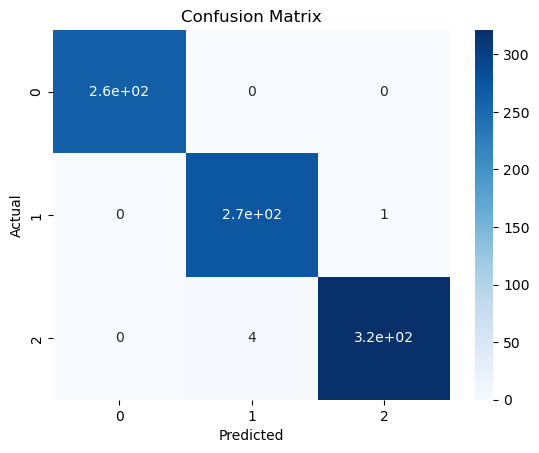

In [11]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

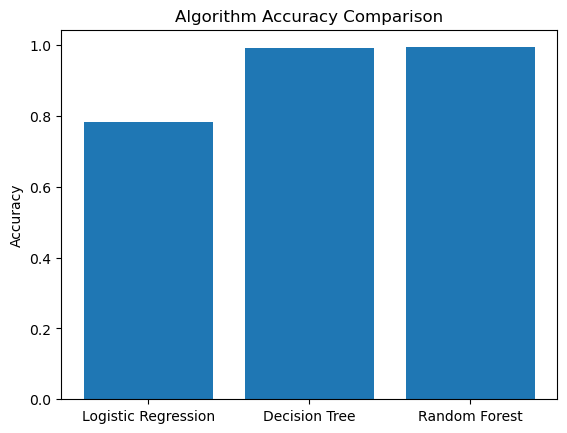

In [12]:
models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracy = [lr_acc, dt_acc, rf_acc]

plt.bar(models, accuracy)
plt.title("Algorithm Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

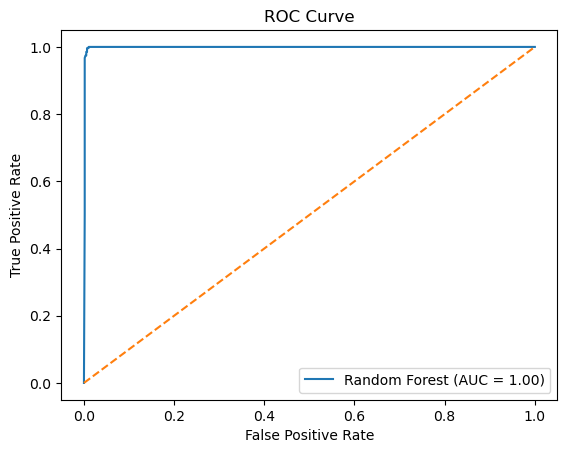

In [14]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Convert target to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])
rf_pred_prob = rf.predict_proba(X_test)

# ROC calculation
fpr, tpr, _ = roc_curve(y_test_bin[:,1], rf_pred_prob[:,1])
roc_auc = auc(fpr, tpr)

# Plot ROC curve
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr, label="Random Forest (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

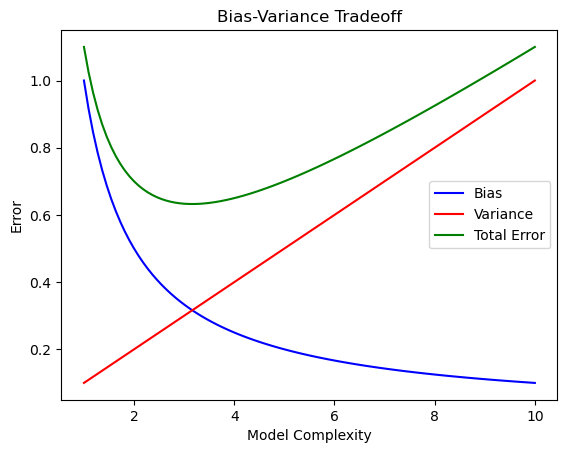

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Model complexity values
complexity = np.linspace(1, 10, 100)

# Example bias and variance curves
bias = 1 / complexity
variance = complexity / 10

total_error = bias + variance

plt.plot(complexity, bias, label="Bias", color="blue")
plt.plot(complexity, variance, label="Variance", color="red")
plt.plot(complexity, total_error, label="Total Error", color="green")

plt.xlabel("Model Complexity")
plt.ylabel("Error")
plt.title("Bias-Variance Tradeoff")
plt.legend()

plt.show()